<a href="https://colab.research.google.com/github/Tejnu/CSET-419---Generative-artificial-intelligence/blob/main/GENAI_LAB_5_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Install & Import Libraries**

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


# **Load Dataset & Create Paired Data**

In [2]:

transform_rgb = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5),
                         (0.5, 0.5, 0.5))
])


transform_gray = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
    transforms.Normalize((0.5,),
                         (0.5,))
])



In [3]:
class PairedCIFAR10(torch.utils.data.Dataset):
    def __init__(self, train=True):
        self.dataset = torchvision.datasets.CIFAR10(
            root='./data',
            train=train,
            download=True
        )

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        img, _ = self.dataset[idx]

        input_img = transform_gray(img)
        target_img = transform_rgb(img)

        return input_img, target_img

In [4]:
train_dataset = PairedCIFAR10(train=True)
test_dataset = PairedCIFAR10(train=False)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

100%|██████████| 170M/170M [00:04<00:00, 35.1MB/s]


# **Model Definition**

In [5]:
class EncoderDecoder(nn.Module):
    def __init__(self):
        super(EncoderDecoder, self).__init__()


        self.encoder = nn.Sequential(
            nn.Conv2d(1, 64, 4, stride=2, padding=1),
            nn.ReLU(True),
            nn.Conv2d(64, 128, 4, stride=2, padding=1),
            nn.ReLU(True),
            nn.Conv2d(128, 256, 4, stride=2, padding=1),
            nn.ReLU(True)
        )


        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(256, 128, 4, stride=2, padding=1),
            nn.ReLU(True),
            nn.ConvTranspose2d(128, 64, 4, stride=2, padding=1),
            nn.ReLU(True),
            nn.ConvTranspose2d(64, 3, 4, stride=2, padding=1),
            nn.Tanh()
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

model = EncoderDecoder().to(device)
print(model)

EncoderDecoder(
  (encoder): Sequential(
    (0): Conv2d(1, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (5): ReLU(inplace=True)
  )
  (decoder): Sequential(
    (0): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): ConvTranspose2d(64, 3, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (5): Tanh()
  )
)


# **Train Function**

In [6]:
def train_model(loss_function, epochs=10):
    model = EncoderDecoder().to(device)
    optimizer = optim.Adam(model.parameters(), lr=0.0002)
    train_losses = []

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0

        for inputs, targets in train_loader:
            inputs = inputs.to(device)
            targets = targets.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = loss_function(outputs, targets)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        epoch_loss = running_loss / len(train_loader)
        train_losses.append(epoch_loss)

        print(f"Epoch [{epoch+1}/{epochs}], Loss: {epoch_loss:.4f}")

    return model, train_losses

# Train MSE Model

In [7]:
print("Training with MSE Loss")
mse_model, mse_losses = train_model(nn.MSELoss(), epochs=30)

Training with MSE Loss
Epoch [1/30], Loss: 0.0667
Epoch [2/30], Loss: 0.0386
Epoch [3/30], Loss: 0.0338
Epoch [4/30], Loss: 0.0313
Epoch [5/30], Loss: 0.0295
Epoch [6/30], Loss: 0.0283
Epoch [7/30], Loss: 0.0274
Epoch [8/30], Loss: 0.0267
Epoch [9/30], Loss: 0.0262
Epoch [10/30], Loss: 0.0256
Epoch [11/30], Loss: 0.0253
Epoch [12/30], Loss: 0.0249
Epoch [13/30], Loss: 0.0246
Epoch [14/30], Loss: 0.0244
Epoch [15/30], Loss: 0.0242
Epoch [16/30], Loss: 0.0239
Epoch [17/30], Loss: 0.0238
Epoch [18/30], Loss: 0.0236
Epoch [19/30], Loss: 0.0234
Epoch [20/30], Loss: 0.0232
Epoch [21/30], Loss: 0.0231
Epoch [22/30], Loss: 0.0229
Epoch [23/30], Loss: 0.0227
Epoch [24/30], Loss: 0.0226
Epoch [25/30], Loss: 0.0225
Epoch [26/30], Loss: 0.0225
Epoch [27/30], Loss: 0.0223
Epoch [28/30], Loss: 0.0222
Epoch [29/30], Loss: 0.0221
Epoch [30/30], Loss: 0.0219


# Train L1 Model

In [8]:
print("Training with L1 Loss")
l1_model, l1_losses = train_model(nn.L1Loss(), epochs=30)

Training with L1 Loss
Epoch [1/30], Loss: 0.1897
Epoch [2/30], Loss: 0.1385
Epoch [3/30], Loss: 0.1275
Epoch [4/30], Loss: 0.1210
Epoch [5/30], Loss: 0.1169
Epoch [6/30], Loss: 0.1139
Epoch [7/30], Loss: 0.1111
Epoch [8/30], Loss: 0.1093
Epoch [9/30], Loss: 0.1079
Epoch [10/30], Loss: 0.1064
Epoch [11/30], Loss: 0.1053
Epoch [12/30], Loss: 0.1044
Epoch [13/30], Loss: 0.1036
Epoch [14/30], Loss: 0.1026
Epoch [15/30], Loss: 0.1018
Epoch [16/30], Loss: 0.1013
Epoch [17/30], Loss: 0.1005
Epoch [18/30], Loss: 0.0998
Epoch [19/30], Loss: 0.0996
Epoch [20/30], Loss: 0.0988
Epoch [21/30], Loss: 0.0986
Epoch [22/30], Loss: 0.0982
Epoch [23/30], Loss: 0.0976
Epoch [24/30], Loss: 0.0974
Epoch [25/30], Loss: 0.0970
Epoch [26/30], Loss: 0.0966
Epoch [27/30], Loss: 0.0962
Epoch [28/30], Loss: 0.0959
Epoch [29/30], Loss: 0.0956
Epoch [30/30], Loss: 0.0957


# **Plot Training Loss Comparison**

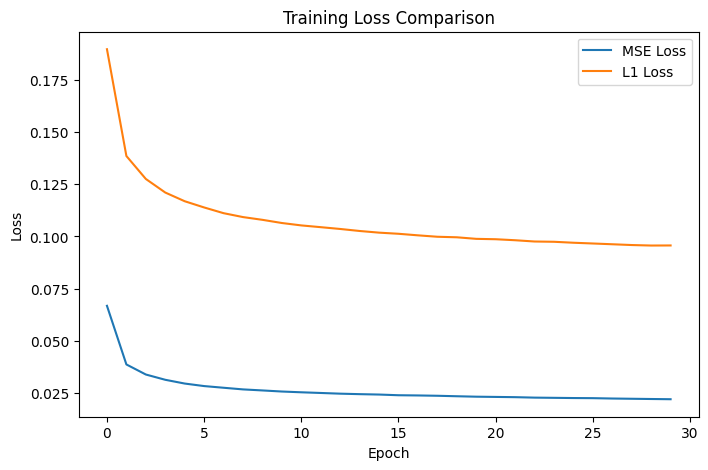

Loss graph saved successfully!


In [9]:
import os

os.makedirs("results", exist_ok=True)

plt.figure(figsize=(8,5))
plt.plot(mse_losses, label="MSE Loss")
plt.plot(l1_losses, label="L1 Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Comparison")
plt.legend()

plt.savefig("results/loss_comparison.png", dpi=300, bbox_inches='tight')

plt.show()

print("Loss graph saved successfully!")

# Visual Comparison

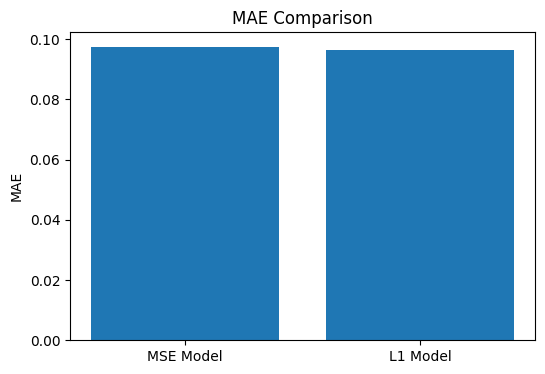

In [10]:
def calculate_mae(model):
    model.eval()
    total_mae = 0
    count = 0

    with torch.no_grad():
        for inputs, targets in test_loader:
            inputs = inputs.to(device)
            targets = targets.to(device)

            outputs = model(inputs)
            mae = nn.functional.l1_loss(outputs, targets)

            total_mae += mae.item()
            count += 1

    return total_mae / count

mse_mae = calculate_mae(mse_model)
l1_mae = calculate_mae(l1_model)

plt.figure(figsize=(6,4))
plt.bar(['MSE Model', 'L1 Model'], [mse_mae, l1_mae])
plt.ylabel("MAE")
plt.title("MAE Comparison")

plt.savefig("results/mae_comparison.png", dpi=300, bbox_inches='tight')
plt.show()

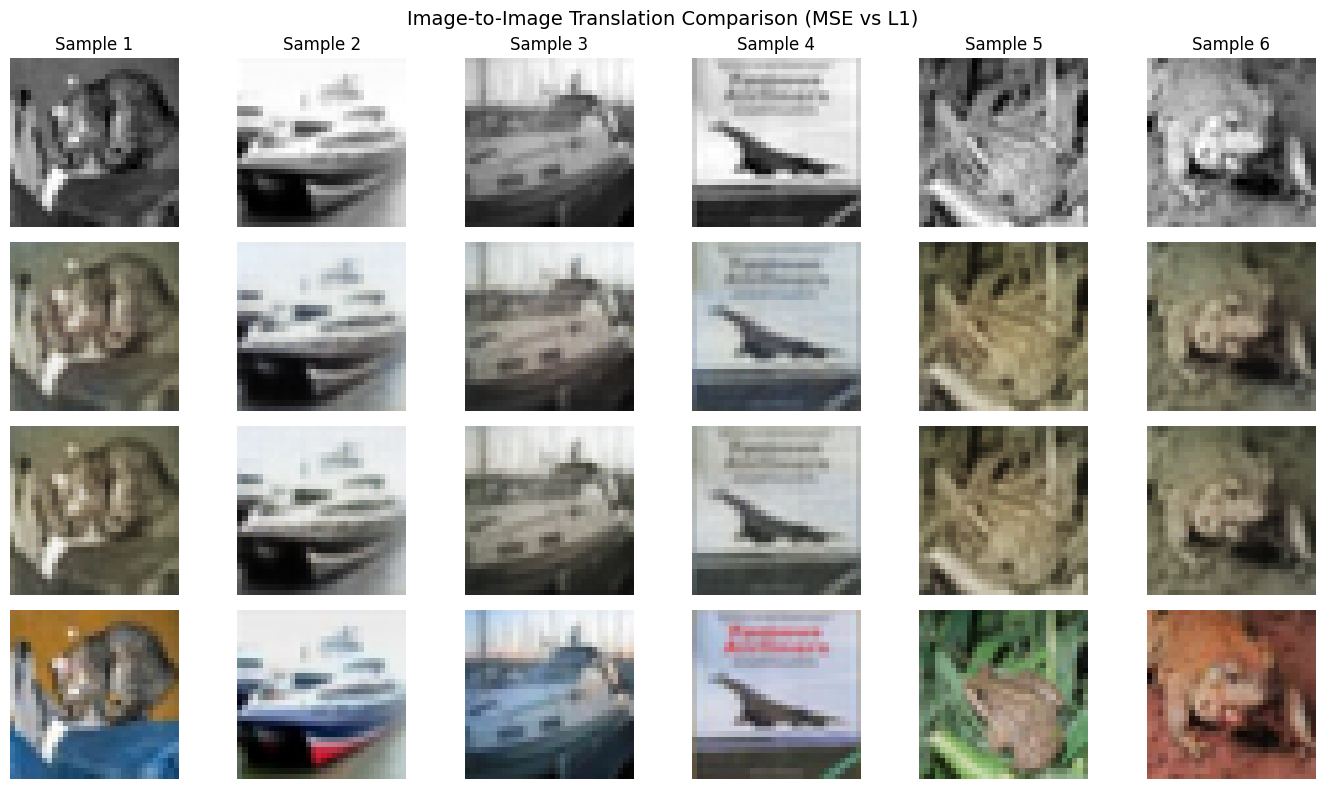

Comparison image saved successfully!


In [11]:

def denormalize(img):
    return img * 0.5 + 0.5

mse_model.eval()
l1_model.eval()

dataiter = iter(test_loader)
inputs, targets = next(dataiter)

inputs = inputs.to(device)
targets = targets.to(device)

with torch.no_grad():
    mse_outputs = mse_model(inputs)
    l1_outputs = l1_model(inputs)

inputs = inputs.cpu()
targets = targets.cpu()
mse_outputs = mse_outputs.cpu()
l1_outputs = l1_outputs.cpu()

fig, axs = plt.subplots(4, 6, figsize=(14,8))

for i in range(6):

    axs[0, i].imshow(inputs[i].squeeze(), cmap='gray')
    axs[0, i].set_title(f"Sample {i+1}")
    axs[0, i].axis("off")


    axs[1, i].imshow(np.transpose(denormalize(mse_outputs[i]).numpy(), (1,2,0)))
    axs[1, i].axis("off")


    axs[2, i].imshow(np.transpose(denormalize(l1_outputs[i]).numpy(), (1,2,0)))
    axs[2, i].axis("off")


    axs[3, i].imshow(np.transpose(denormalize(targets[i]).numpy(), (1,2,0)))
    axs[3, i].axis("off")

axs[0,0].set_ylabel("Input\n(Grayscale)", fontsize=12)
axs[1,0].set_ylabel("MSE Output", fontsize=12)
axs[2,0].set_ylabel("L1 Output", fontsize=12)
axs[3,0].set_ylabel("Ground Truth", fontsize=12)

plt.suptitle("Image-to-Image Translation Comparison (MSE vs L1)", fontsize=14)

plt.tight_layout()
plt.subplots_adjust(top=0.92)

plt.savefig("results/mse_vs_l1_visual_comparison.png", dpi=300, bbox_inches='tight')

plt.show()

print("Comparison image saved successfully!")